# <font color="blue">1. Redes Generativas Adversarias (GANs) <font>

Durante gran parte de este curso hemos trabajado con modelos que realizan predicciones, es decir, que aprenden a partir de ejemplos cómo asignar etiquetas a datos. Este tipo de aprendizaje se conoce como **discriminativo**, y se utiliza en tareas como clasificar imágenes de animales, reconocer dígitos o predecir precios.

Sin embargo, el aprendizaje automático no se limita a clasificar o predecir. Tal como lo vimos en las redes autoencoders, donde queremos que un modelo aprenda las características subyacentes de un conjunto de datos sin necesidad de etiquetas. Con esta información, sería posible **generar nuevos ejemplos** que parezcan reales y pertenezcan a la misma distribución que los datos originales.
Por ejemplo, podríamos entrenar un modelo con miles de fotos de rostros y luego pedirle que cree una imagen completamente nueva que luzca auténtica. Este enfoque se conoce como **aprendizaje generativo**.


![](https://techaffinity.com/blog/wp-content/uploads/2023/08/138_2021_1208_Fig2_HTML-2.webp)


Hasta hace algunos años, crear imágenes realistas desde cero era una tarea muy difícil. Sin embargo, el avance de las redes neuronales profundas abrió nuevas posibilidades. Un enfoque reciente y poderoso ha sido usar redes que originalmente se diseñaron para clasificación, adaptándolas a tareas generativas.

Un caso notable es el de los **modelos de lenguaje**, donde una red entrenada para predecir el siguiente carácter puede también generar texto coherente. Inspirados por esto, en 2014 surgió un enfoque revolucionario: las **Redes Generativas Adversarias (GANs)**.

La idea detrás de las GAN es simple pero poderosa: si un generador es lo suficientemente bueno, sus datos sintéticos deberían ser indistinguibles de los datos reales. Este principio se basa en una prueba estadística llamada prueba de dos muestras, la cual busca determinar si dos conjuntos de datos provienen de la misma distribución.

En lugar de solo usar esta prueba como verificación, las GAN la convierten en una herramienta de entrenamiento. Así, el generador se mejora constantemente hasta que logra "engañar" a un clasificador (también llamado discriminador), haciéndole creer que sus datos falsos son reales.


![Arquitectura de una GAN](https://i.imgur.com/ya1gA5H.png)

La figura anterior muestra cómo se organiza una arquitectura GAN.

Este tipo de red consta de dos partes principales: por un lado, tenemos una **red generadora**, cuya tarea es producir datos que imiten a los reales. Si trabajamos con imágenes, debe generar imágenes; si tratamos audio, entonces secuencias de sonido, y así con cualquier tipo de dato.

Por otro lado, existe una **red discriminadora**, cuyo rol es detectar si los datos que recibe son reales o fueron generados artificialmente. Ambas redes están en constante competencia: el generador intenta "engañar" al discriminador, y este último se entrena para no ser engañado. El ciclo se repite, y con el tiempo ambos modelos mejoran.


El discriminador funciona como un clasificador binario. Su tarea es decidir si una muestra $x$ proviene de los datos reales o fue generada por el modelo. Generalmente, emite una salida escalar $o$, que luego se transforma con una función sigmoidea:

$$
D(\mathbf{x}) = \frac{1}{1 + e^{-o}}.
$$

Asignamos la etiqueta $y=1$ para datos reales y $y=0$ para datos generados. El discriminador se entrena minimizando la pérdida de entropía cruzada:

$$
\min_D \left\{ - y \log D(\mathbf{x}) - (1 - y) \log (1 - D(\mathbf{x})) \right\}.
$$

El generador, en cambio, parte de una variable aleatoria $\mathbf{z} \sim \mathcal{N}(0, 1)$ (llamada variable latente) y genera una muestra sintética $\mathbf{x}' = G(\mathbf{z})$.

Su objetivo es lograr que el discriminador no detecte que sus datos son falsos, es decir, que $D(G(\mathbf{z})) \approx 1$. Para ello, ajustamos los parámetros de $G$ maximizando la pérdida cuando $y = 0$:

$$
\max_G \left\{ - \log(1 - D(G(\mathbf{z}))) \right\}.
$$

No obstante, cuando el generador es bueno y el discriminador se deja engañar, los gradientes pueden volverse muy pequeños, dificultando el aprendizaje. Por eso, una práctica común es cambiar la función objetivo del generador a:

$$
\min_G \left\{ - \log(D(G(\mathbf{z}))) \right\},
$$

lo que equivale a hacer pasar los datos falsos por el discriminador fingiendo que son reales.

En conjunto, ambos modelos se entrenan en un juego tipo "minimax", con la siguiente función objetivo:

$$
\min_D \max_G \left\{
- \mathbb{E}_{\mathbf{x} \sim \text{Datos}} [\log D(\mathbf{x})] -
\mathbb{E}_{\mathbf{z} \sim \text{Ruido}} [\log(1 - D(G(\mathbf{z})))]
\right\}.
$$

Aunque muchas aplicaciones de las GAN están relacionadas con imágenes, comenzaremos con un caso más simple para fines demostrativos: ajustaremos una distribución normal utilizando este enfoque.



# <font color="blue">2.  Taller 1. GAN en Keras para generar dígitos (MNIST) </font>
Este notebook implementa una GAN simple utilizando Keras y TensorFlow para generar imágenes de dígitos manuscritos del conjunto de datos MNIST.


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

# Cargar y preparar datos MNIST
(x_train, _), (_, _) = tf.keras.datasets.mnist.load_data()


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [2]:
#mostrar 5 numeros de x_train y el tamaño de la imagen 
print("Tamaño de x_train:", x_train.shape)
print(x_train[0])

Tamaño de x_train: (60000, 28, 28, 1)
[[[-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]]

 [[-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]]

 [[-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        

#Ver las imagenes cargadas
Vamos a mostrar la grilla de 25 dígitos manuscritos.
x_train[i].squeeze() elimina la dimensión extra del canal (pasamos de (28, 28, 1) a (28, 28)).

cmap='gray' se usa porque las imágenes de MNIST son en escala de grises.

plt.axis('off') elimina los ejes para una visualización más limpia.



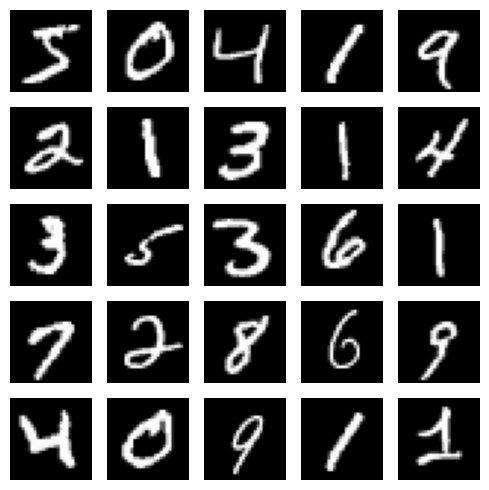

raw data of the first image (x_train[0]):
(28, 28, 1)


In [7]:
import matplotlib.pyplot as plt

# Mostrar una grilla de 25 imágenes del dataset MNIST
plt.figure(figsize=(5,5))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(x_train[i].squeeze(), cmap='gray')
    plt.axis('off')
plt.tight_layout()
plt.show()

print("raw data of the first image (x_train[0]):")
print(x_train[0].shape)


#Preparar los datos para tensores

preparamos el dataset correctamente para entrenar la GAN:

BUFFER_SIZE = 60000: el tamaño del conjunto de datos (todo MNIST), usado para el barajado.

BATCH_SIZE = 128: cantidad de ejemplos por lote.

LATENT_DIM = 100: dimensión del vector aleatorio de entrada al generador (espacio latente).

In [8]:
print(x_train[0])

[[[-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]]

 [[-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]]

 [[-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-1.        ]
  [-

In [9]:
BUFFER_SIZE = 60000
BATCH_SIZE = 64

dataset = tf.data.Dataset.from_tensor_slices(x_train).shuffle(BUFFER_SIZE).batch(BATCH_SIZE)

LATENT_DIM = 100


### Definición del Generador

El generador es una red neuronal que toma como entrada un vector de ruido de dimensión `LATENT_DIM` (por ejemplo, 100 valores aleatorios) y genera imágenes falsas similares a las del conjunto MNIST.

Se construye utilizando una red neuronal secuencial que:
- Comienza con una capa `Dense` que proyecta el vector latente a una forma intermedia de 7x7x256.
- Aplica normalización por lotes (`BatchNormalization`) y activación `LeakyReLU` para mejorar la estabilidad del entrenamiento.
- Utiliza varias capas `Conv2DTranspose` (convoluciones transpuestas) para ir ampliando progresivamente la resolución de la imagen hasta alcanzar 28x28x1, que es el tamaño de las imágenes MNIST.
- La última capa utiliza la activación `tanh` para que los valores de salida estén en el rango [-1, 1], en concordancia con la normalización del dataset.

Este generador se entrenará para "engañar" al discriminador produciendo imágenes que parezcan reales.


In [10]:
def build_generator():
    model = tf.keras.Sequential([
        tf.keras.Input(shape=(LATENT_DIM,)),  # Entrada explícita
        layers.Dense(7*7*256, use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Reshape((7, 7, 256)),

        layers.Conv2DTranspose(128, (5,5), strides=(1,1), padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Conv2DTranspose(64, (5,5), strides=(2,2), padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Conv2DTranspose(1, (5,5), strides=(2,2), padding='same', use_bias=False, activation='tanh')
    ])
    return model


In [11]:
generator = build_generator()
generator.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12544)          │     1,254,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 12544)          │        50,176 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 7, 7, 128)      │       819,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 14, 14, 64)     │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │         1,600 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,330,944 (8.89 MB)

 Trainable params: 2,305,472 (8.79 MB)

 Non-trainable params: 25,472 (99.50 KB)

### Definición del Discriminador

El discriminador es una red neuronal convolucional que recibe una imagen de tamaño 28x28x1 (ya sea real del conjunto MNIST o generada por el generador) y devuelve un valor escalar que representa la probabilidad de que la imagen sea real.

Estructura del modelo:
- Comienza con una capa `Conv2D` para extraer características espaciales, seguida por una activación `LeakyReLU` y `Dropout` para evitar el sobreajuste.
- Se repite un segundo bloque convolucional con más filtros para captar características más complejas.
- Se aplana la salida con `Flatten`, y finalmente se conecta a una capa `Dense` de salida con un único valor.

**Nota**: No se aplica una función de activación en la salida (`sigmoid` o `softmax`) porque se usará la pérdida `BinaryCrossentropy(from_logits=True)`, que internamente aplica `sigmoid`.

El discriminador será entrenado para distinguir correctamente entre imágenes reales y generadas (falsas).


In [12]:
def build_discriminator():
    model = tf.keras.Sequential([
        tf.keras.Input(shape=(28, 28, 1)),  # Imágenes MNIST normalizadas [-1, 1]

        layers.Conv2D(32, (5,5), strides=(2,2), padding='same'),
        layers.LeakyReLU(),
        layers.Dropout(0.2),

        layers.Conv2D(64, (5,5), strides=(2,2), padding='same'),
        layers.LeakyReLU(),
        layers.Dropout(0.2),

        layers.Flatten(),
        layers.Dense(1)  # Salida: puntuación real/falsa (sin activación)
    ])
    return model

discriminator = build_discriminator()
discriminator.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 14, 14, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 64)       │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         3,137 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,233 (215.75 KB)

 Trainable params: 55,233 (215.75 KB)

 Non-trainable params: 0 (0.00 B)

### Funciones de Pérdida y Optimizadores

Se define la función de pérdida binaria cruzada (`BinaryCrossentropy`) con `from_logits=True` ya que el discriminador no usa activación en la salida.

- **Discriminador**: debe distinguir correctamente entre imágenes reales y falsas. Su pérdida es la suma del error al clasificar imágenes reales como reales (`1`) y falsas como falsas (`0`).

- **Generador**: su objetivo es "engañar" al discriminador, así que su pérdida se calcula haciendo que las imágenes falsas sean clasificadas como reales (`1`).

Se utilizan optimizadores Adam con una tasa de aprendizaje de `1e-4` para ambos modelos.


In [13]:
# Función de pérdida binaria cruzada
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

# Pérdida del discriminador
def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)  # etiquetas reales = 1
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)  # etiquetas falsas = 0
    return real_loss + fake_loss

# Pérdida del generador (quiere que el discriminador piense que las falsas son reales)
def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)  # etiqueta real = 1


In [14]:
generator_optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)

### Paso de Entrenamiento

Aquí se define `train_step()`, que ejecuta una iteración de entrenamiento:

1. Se genera un lote de ruido aleatorio (vector latente) y se pasan por el generador para obtener imágenes falsas.
2. El discriminador evalúa tanto imágenes reales como falsas.
3. Se calculan las pérdidas para el generador y el discriminador.
4. Se computan y aplican los gradientes a ambos modelos usando `GradientTape`.

Este paso se repetirá muchas veces en el bucle principal de entrenamiento.


In [15]:
@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, LATENT_DIM])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))


### Entrenamiento Completo y Visualización

Se define la función `train()` que entrena la GAN durante un número dado de épocas. Dentro de cada época:

1. Se itera sobre todos los lotes del dataset y se aplica `train_step()` para actualizar los modelos.
2. Al finalizar cada época, se generan 16 imágenes a partir de una semilla fija y se muestran en una grilla de 4x4. Esto permite visualizar cómo evoluciona la calidad de las imágenes generadas con el entrenamiento.
3. Se imprime el tiempo de ejecución por época para tener una idea del rendimiento.

La semilla fija garantiza una comparación consistente entre épocas.


In [16]:
import matplotlib.pyplot as plt

# Semilla fija para ver el progreso consistente a lo largo del tiempo
seed = tf.random.normal([16, LATENT_DIM])

def generate_and_plot_images(model, epoch, test_input=seed):
    predictions = model(test_input, training=False)

    plt.figure(figsize=(4,4))
    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i+1)
        plt.imshow(predictions[i, :, :, 0] * 127.5 + 127.5, cmap='gray')  # desnormalizar
        plt.axis('off')
    plt.suptitle(f'Época {epoch}', fontsize=14)
    plt.tight_layout()
    plt.show()


In [17]:
import time

def train(dataset, epochs):
    for epoch in range(1, epochs + 1):
        start = time.time()

        for image_batch in dataset:
            train_step(image_batch)

        # Mostrar imágenes generadas al final de cada época
        generate_and_plot_images(generator, epoch)

        print(f'Tiempo para la época {epoch}: {time.time() - start:.2f} segundos')


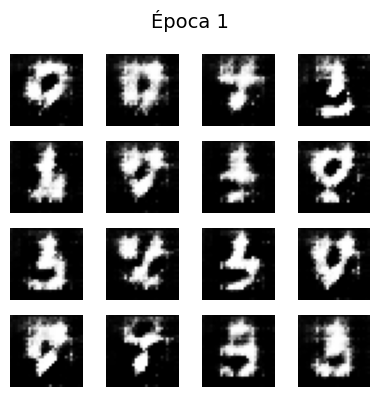

Tiempo para la época 1: 19.35 segundos


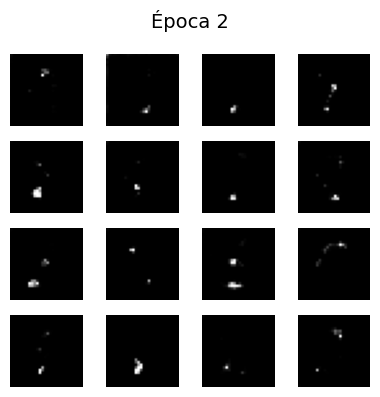

Tiempo para la época 2: 11.79 segundos


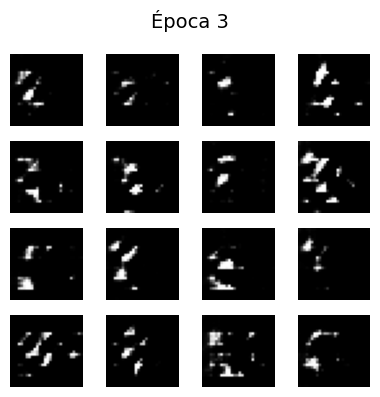

Tiempo para la época 3: 11.88 segundos


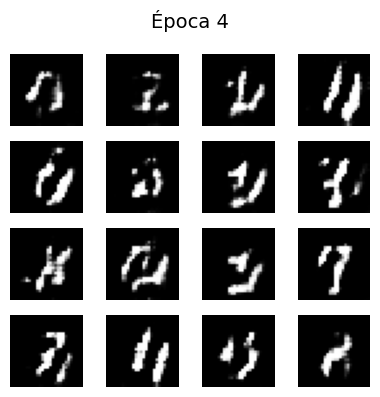

Tiempo para la época 4: 11.98 segundos


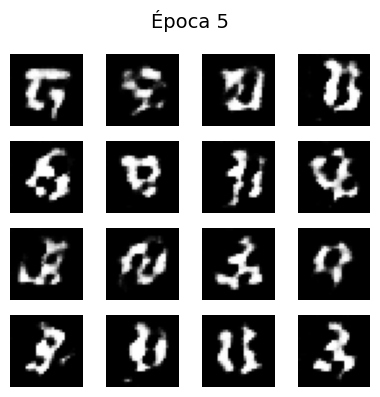

Tiempo para la época 5: 12.44 segundos


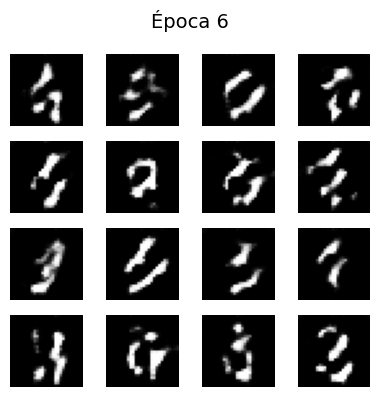

Tiempo para la época 6: 12.24 segundos


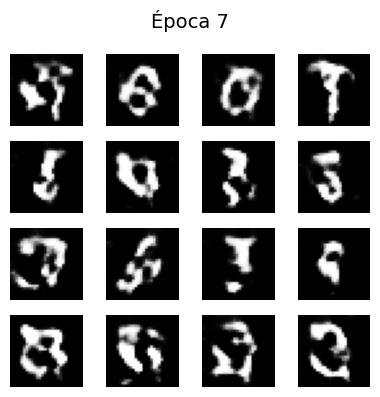

Tiempo para la época 7: 12.34 segundos


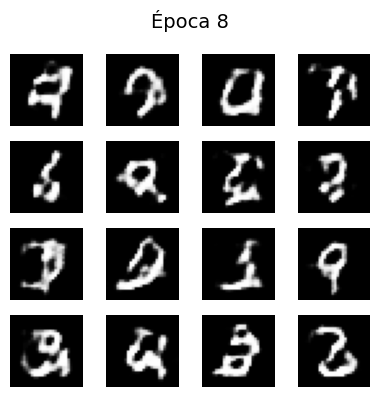

Tiempo para la época 8: 12.43 segundos


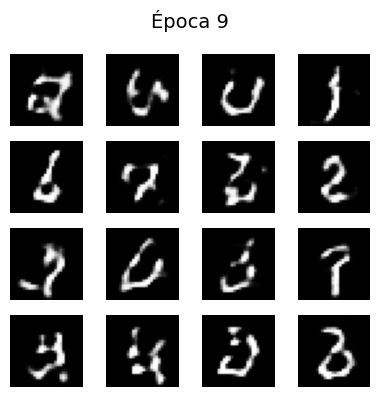

Tiempo para la época 9: 12.67 segundos


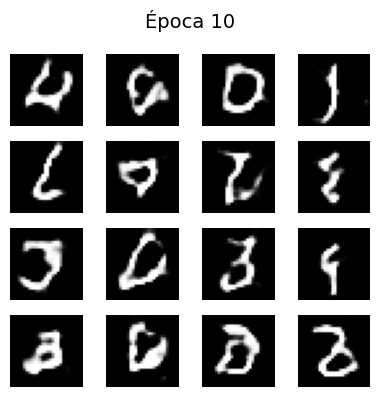

Tiempo para la época 10: 12.72 segundos


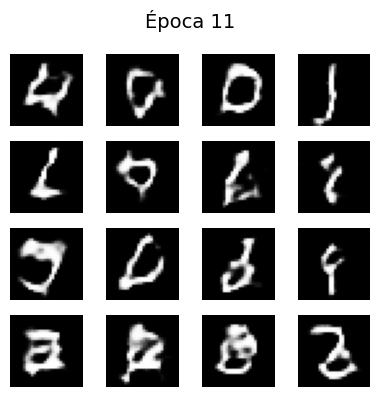

Tiempo para la época 11: 13.19 segundos


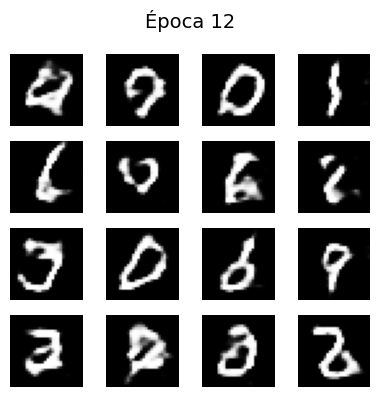

Tiempo para la época 12: 12.70 segundos


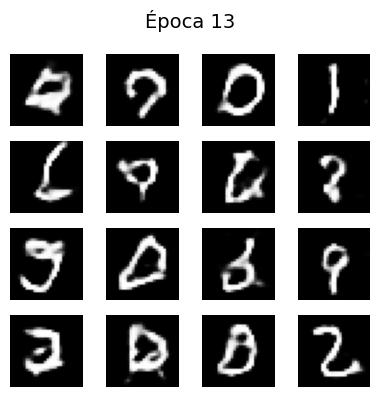

Tiempo para la época 13: 12.75 segundos


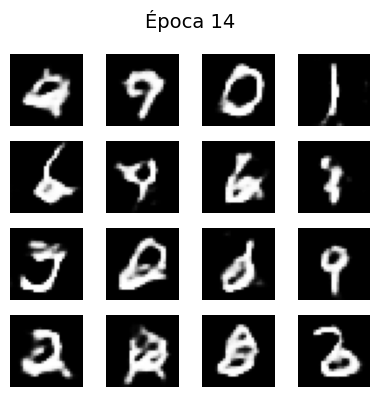

Tiempo para la época 14: 12.82 segundos


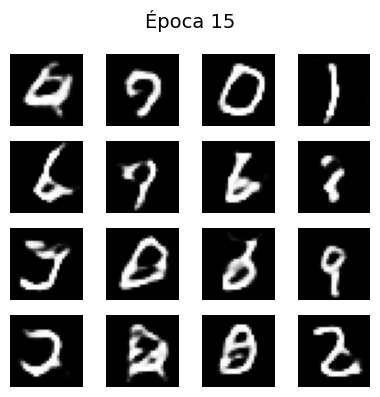

Tiempo para la época 15: 12.85 segundos


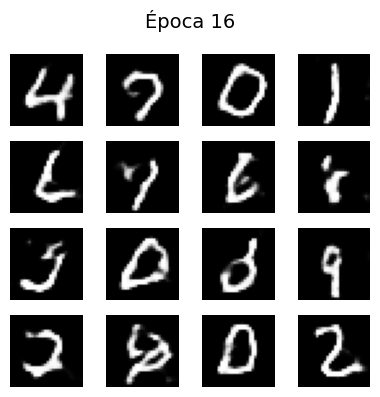

Tiempo para la época 16: 12.87 segundos


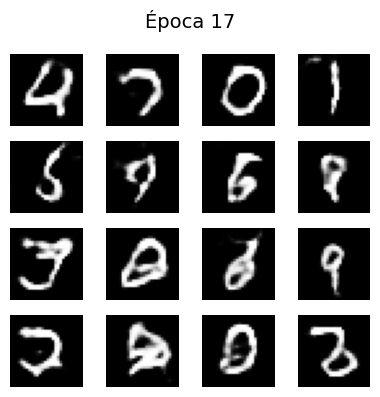

Tiempo para la época 17: 12.86 segundos


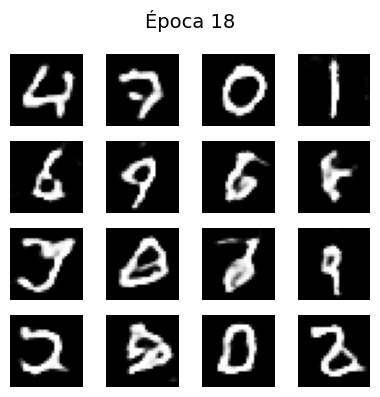

Tiempo para la época 18: 13.14 segundos


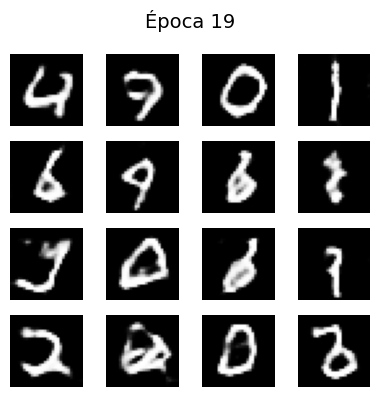

Tiempo para la época 19: 12.85 segundos


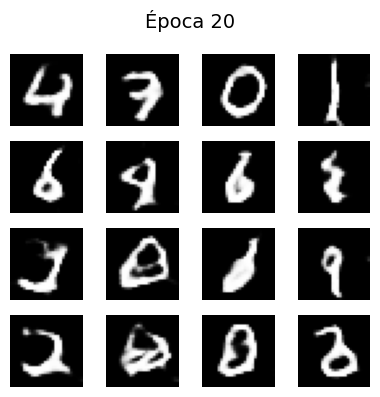

Tiempo para la época 20: 12.85 segundos


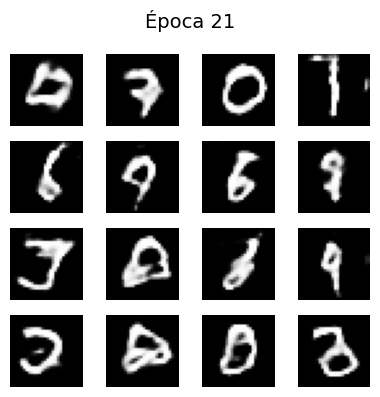

Tiempo para la época 21: 20.69 segundos


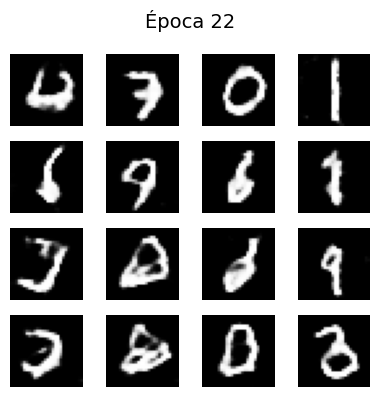

Tiempo para la época 22: 12.82 segundos


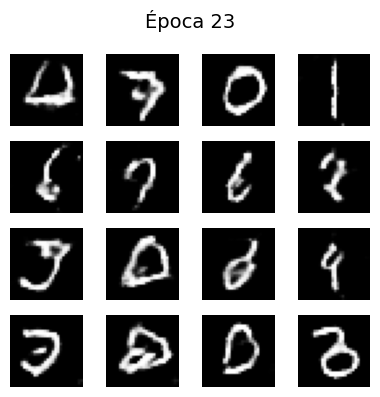

Tiempo para la época 23: 13.01 segundos


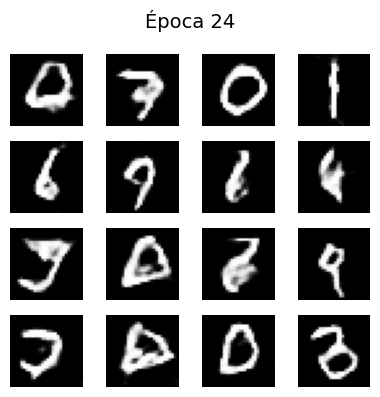

Tiempo para la época 24: 13.30 segundos


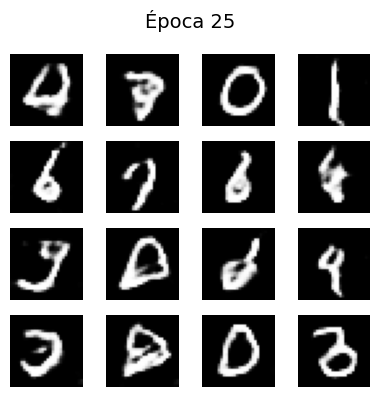

Tiempo para la época 25: 12.89 segundos


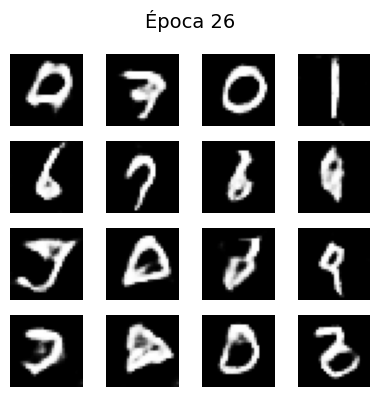

Tiempo para la época 26: 12.76 segundos


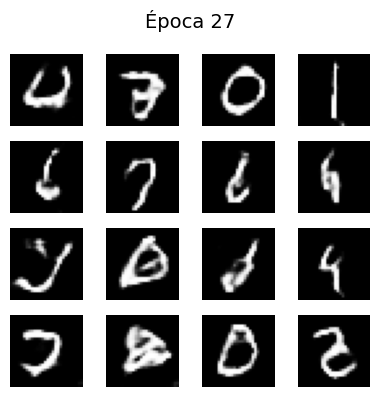

Tiempo para la época 27: 12.75 segundos


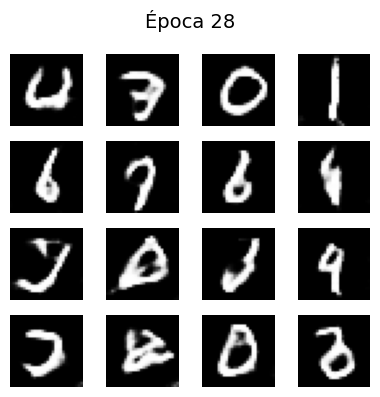

Tiempo para la época 28: 12.81 segundos


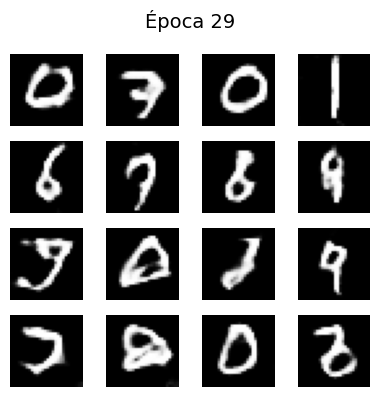

Tiempo para la época 29: 12.87 segundos


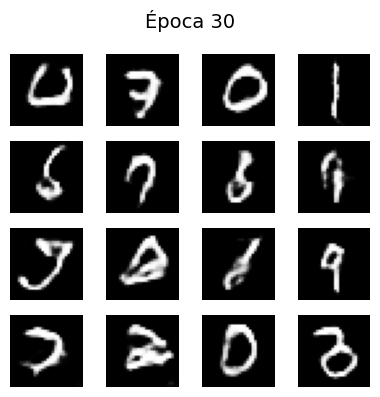

Tiempo para la época 30: 13.40 segundos


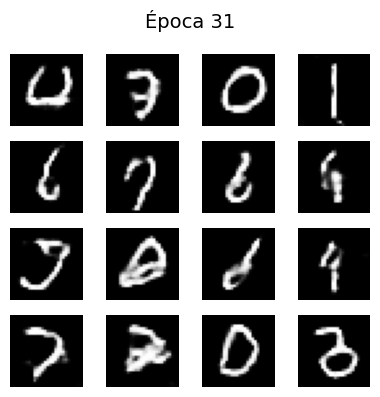

Tiempo para la época 31: 12.97 segundos


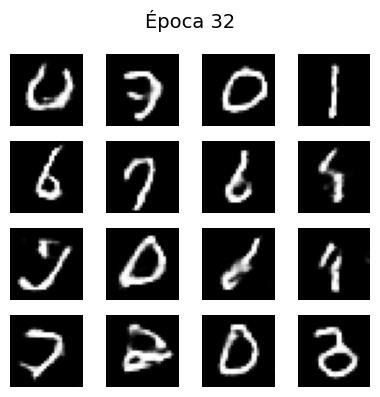

Tiempo para la época 32: 12.98 segundos


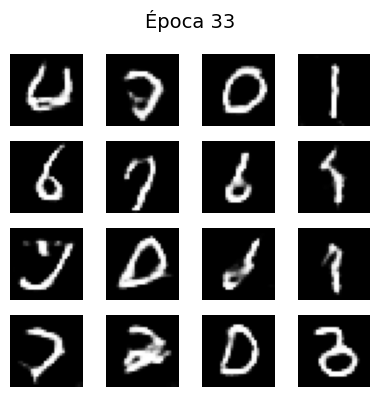

Tiempo para la época 33: 12.83 segundos


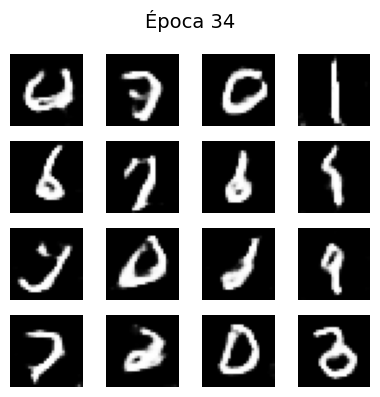

Tiempo para la época 34: 12.83 segundos


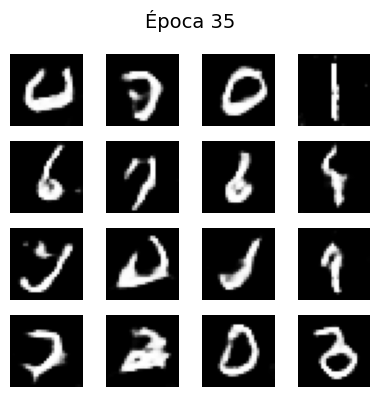

Tiempo para la época 35: 12.83 segundos


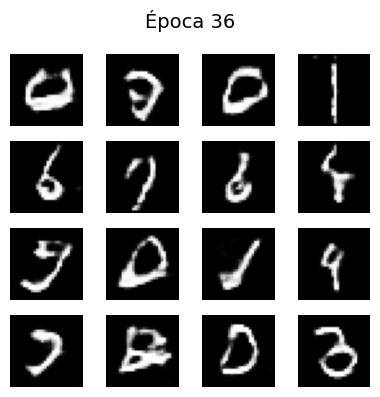

Tiempo para la época 36: 13.13 segundos


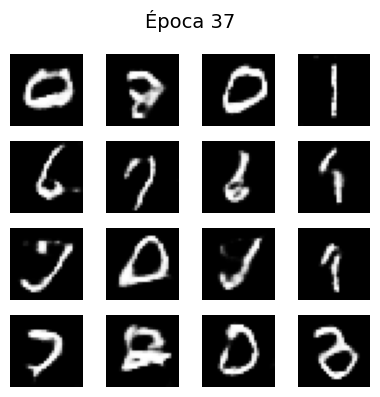

Tiempo para la época 37: 12.85 segundos


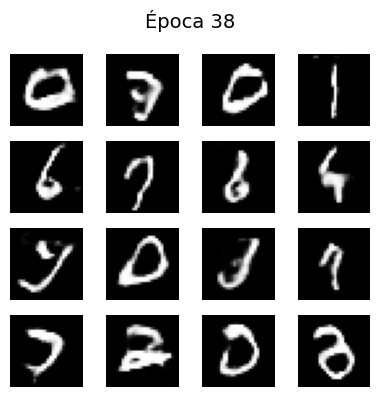

Tiempo para la época 38: 12.83 segundos


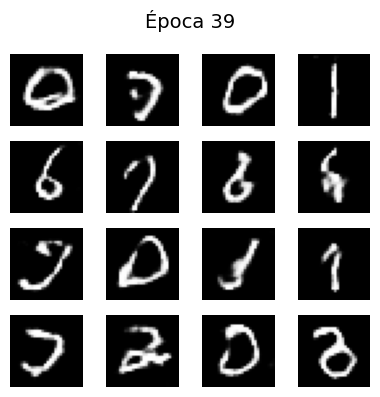

Tiempo para la época 39: 12.85 segundos


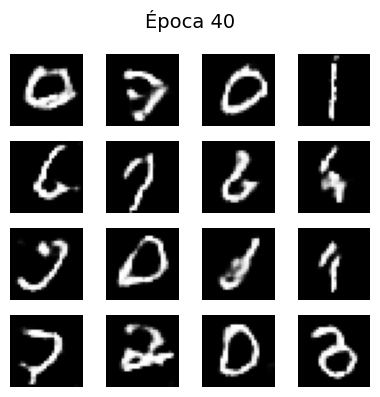

Tiempo para la época 40: 12.86 segundos


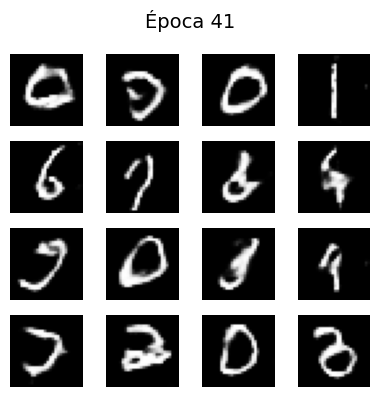

Tiempo para la época 41: 12.83 segundos


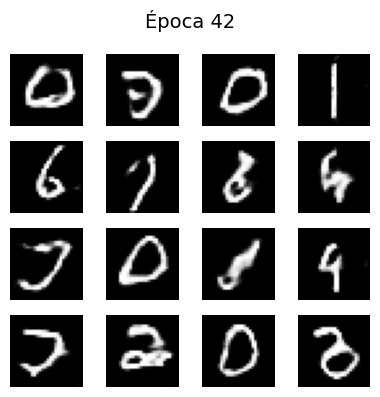

Tiempo para la época 42: 12.90 segundos


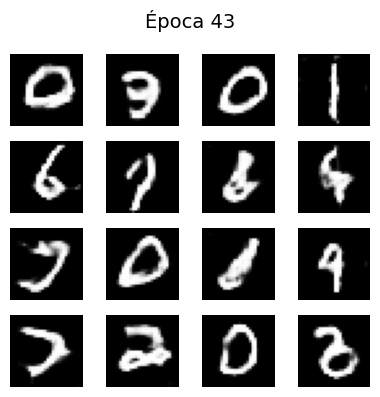

Tiempo para la época 43: 13.21 segundos


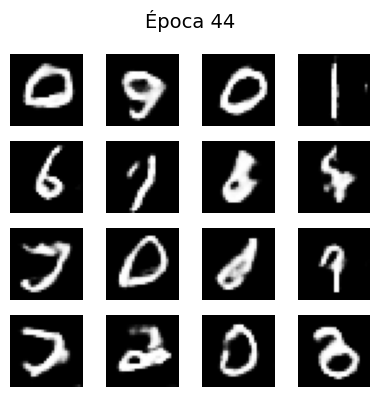

Tiempo para la época 44: 12.85 segundos


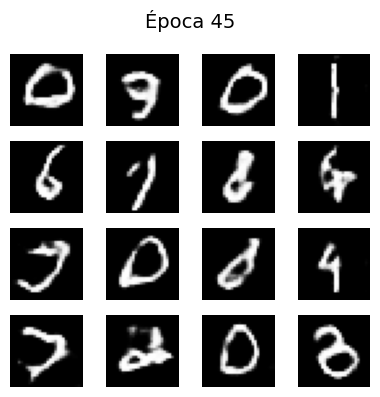

Tiempo para la época 45: 12.81 segundos


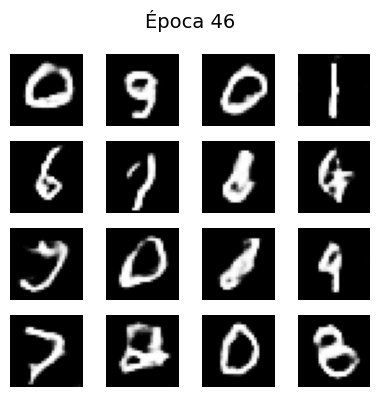

Tiempo para la época 46: 12.89 segundos


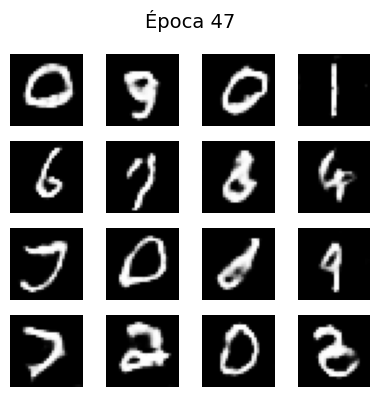

Tiempo para la época 47: 12.95 segundos


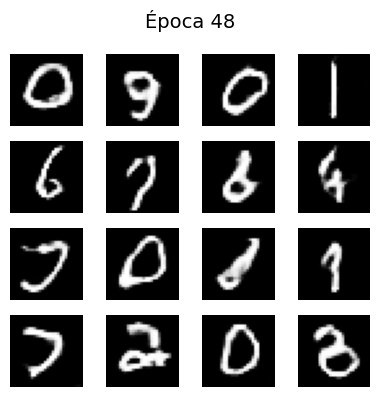

Tiempo para la época 48: 12.98 segundos


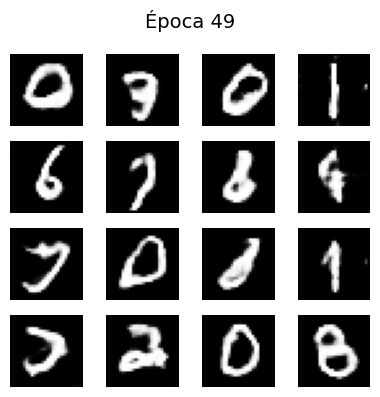

Tiempo para la época 49: 13.15 segundos


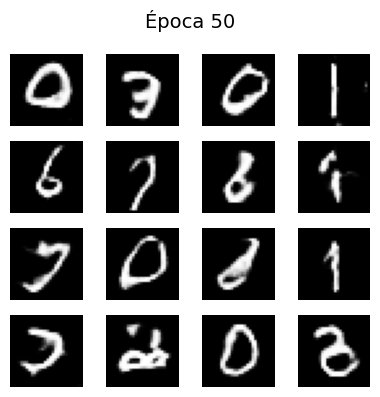

Tiempo para la época 50: 12.79 segundos


In [18]:
EPOCHS = 50
train(dataset, EPOCHS)